# Notebook 09 — Pipeline, Automation & Deployment

**Project:** Mirae Asset Digital Platform — User Analytics  
**Phases covered:** Phase 20 · Phase 21 · Phase 22 · Phase 27  
**Objective:** Turn the analytics project into a reproducible, automated, deployable system.  

| Deliverable | What | Where |
|-------------|------|-------|
| `pipeline.py` | Automated data refresh | `scripts/pipeline.py` |
| `app.py` | Streamlit dashboard (4 tabs — RFM + K-Means segmentation) | `app/app.py` |
| `README.md` | Project documentation (27-phase roadmap, correct NB table) | `README.md` |
| `requirements.txt` | Python dependencies for pip install | `requirements.txt` |
| `.gitignore` | Excludes CSVs, checkpoints, pycache from Git | `.gitignore` |

| Phase | Focus | Output |
|-------|-------|--------|
| 27 | Data Pipeline Architecture | System diagram |
| 20 | Automation Pipeline | `pipeline.py` |
| 21 | Streamlit Deployment | `app.py` |
| 22 | Documentation | `README.md`, `requirements.txt`, `.gitignore` |


## Table of Contents

**Phase 27 — Architecture**  
27.1 [System Overview](#271)  
27.2 [Data Flow Diagram](#272)  

**Phase 20 — Automation Pipeline**  
20.1 [Pipeline Design](#201)  
20.2 [Generate pipeline.py](#202)  
20.3 [Test Run](#203)  

**Phase 21 — Streamlit Dashboard**  
21.1 [Dashboard Design](#211)  
21.2 [Launch Instructions](#213)  

**Phase 22 — Documentation**  
22.1 [Project Summary](#222)  


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
import os, shutil

# Update BASE if your project is in a different location
BASE = r'C:\Users\HP\Desktop\Mirae Asset major'

user_data    = pd.read_csv(os.path.join(BASE,'data','processed','user_data.csv'),
                            parse_dates=['signup_date','last_active_date','first_purchase_date'])
transactions = pd.read_csv(os.path.join(BASE,'data','raw','transactions.csv'),
                            parse_dates=['transaction_date'])
sessions     = pd.read_csv(os.path.join(BASE,'data','raw','sessions.csv'),
                            parse_dates=['session_date'])
campaigns    = pd.read_csv(os.path.join(BASE,'data','raw','campaigns.csv'),
                            parse_dates=['start_date'])

user_data['churn']           = user_data['churn'].astype(int)
user_data['has_purchased']   = user_data['has_purchased'].astype(int)
user_data['total_sessions']  = user_data['total_sessions'].astype(int)
user_data['total_purchases'] = user_data['total_purchases'].astype(int)

transactions['month']       = transactions['transaction_date'].dt.to_period('M')
transactions['month_str']   = transactions['month'].astype(str)
transactions['day_of_week'] = transactions['transaction_date'].dt.day_name()

print(f'Users        : {len(user_data):,}')
print(f'Transactions : {len(transactions):,}')
print(f'BASE         : {BASE}')


Users        : 10,000
Transactions : 15,000
BASE         : C:\Users\HP\Desktop\Mirae Asset major


---
## Phase 27 — Data Pipeline Architecture

> Document the system before writing any code. Architecture thinking shows you understand where your work fits in a real data stack.


### 27.1 System Architecture Overview


In [2]:
print('='*65)
print('  MIRAE ASSET ANALYTICS — SYSTEM ARCHITECTURE')
print('='*65)
print()
print('LAYER 1 — RAW DATA  (data/raw/)')
print('  users.csv       10,000 rows | demographics')
print('  sessions.csv     ~30K rows  | session events')
print('  transactions.csv 15,000 rows| purchase records')
print('  events.csv       ~80K rows  | funnel events')
print('  campaigns.csv    50 rows    | marketing spend')
print()
print('LAYER 2 — PROCESSING  (scripts/pipeline.py)')
print('  Aggregate session + transaction metrics per user')
print('  Derive features: recency, revenue ratios, engagement score')
print('  Flag churn (30-day inactivity)')
print('  Output: data/processed/user_data.csv  (10K x 25)')
print()
print('LAYER 3 — ANALYTICS  (notebooks/)')
print('  NB01-08: 27 phases of analysis')
print()
print('LAYER 4 — PRESENTATION  (app/app.py)')
print('  Streamlit dashboard | localhost:8501')
print('  Tabs: KPI Overview | Revenue | Churn | Segmentation')
print()
print('REFRESH CYCLE')
print('  new data -> python scripts/pipeline.py -> dashboard auto-updates')
print('='*65)


  MIRAE ASSET ANALYTICS — SYSTEM ARCHITECTURE

LAYER 1 — RAW DATA  (data/raw/)
  users.csv       10,000 rows | demographics
  sessions.csv     ~30K rows  | session events
  transactions.csv 15,000 rows| purchase records
  events.csv       ~80K rows  | funnel events
  campaigns.csv    50 rows    | marketing spend

LAYER 2 — PROCESSING  (scripts/pipeline.py)
  Aggregate session + transaction metrics per user
  Derive features: recency, revenue ratios, engagement score
  Flag churn (30-day inactivity)
  Output: data/processed/user_data.csv  (10K x 25)

LAYER 3 — ANALYTICS  (notebooks/)
  NB01-08: 27 phases of analysis

LAYER 4 — PRESENTATION  (app/app.py)
  Streamlit dashboard | localhost:8501
  Tabs: KPI Overview | Revenue | Churn | Segmentation

REFRESH CYCLE
  new data -> python scripts/pipeline.py -> dashboard auto-updates


### 27.2 Data Flow Diagram


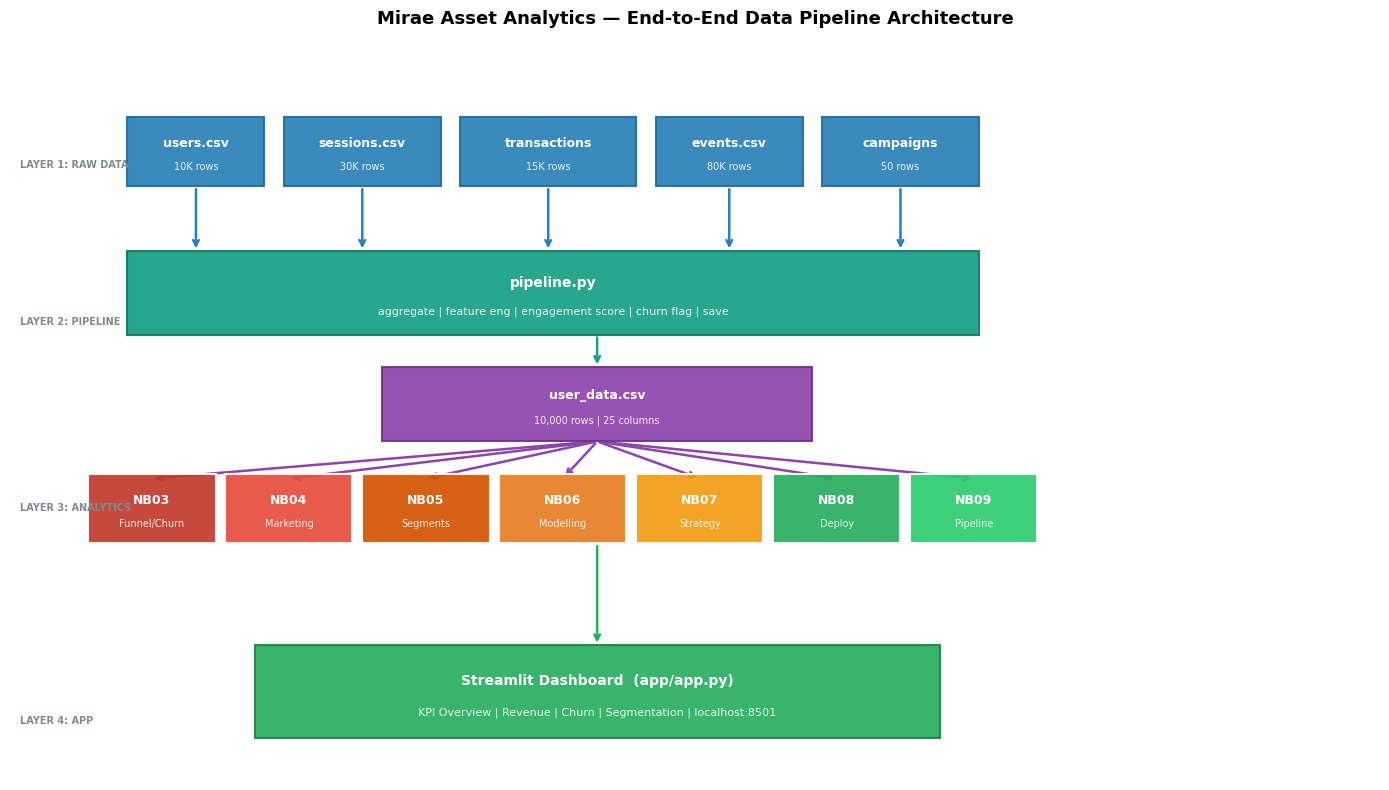

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 8)
ax.axis('off')

# ---------- FUNCTIONS ----------
def draw_box(ax, x, y, w, h, title, subtitle, fc, ec='white', fs=9):
    r = plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec,
                      linewidth=1.5, zorder=2, alpha=0.92)
    ax.add_patch(r)
    
    ax.text(x + w/2, y + h*0.62, title,
            ha='center', va='center',
            fontsize=fs, fontweight='bold', color='white')
    
    if subtitle:
        ax.text(x + w/2, y + h*0.28, subtitle,
                ha='center', va='center',
                fontsize=max(fs-2, 7), color='white', alpha=0.88)

def draw_arrow(ax, x1, y1, x2, y2, color='#555'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8),
                zorder=1)

# ---------- LAYER LABELS ----------
for ly, ltxt in [(6.6,'LAYER 1: RAW DATA'),
                 (4.9,'LAYER 2: PIPELINE'),
                 (2.9,'LAYER 3: ANALYTICS'),
                 (0.6,'LAYER 4: APP')]:
    ax.text(0.1, ly, ltxt, fontsize=7,
            color='#7f8c8d', fontweight='bold')

# ---------- RAW DATA ----------
raw = [
    (1.2,6.4,1.4,0.75,'users.csv','10K rows'),
    (2.8,6.4,1.6,0.75,'sessions.csv','30K rows'),
    (4.6,6.4,1.8,0.75,'transactions','15K rows'),
    (6.6,6.4,1.5,0.75,'events.csv','80K rows'),
    (8.3,6.4,1.6,0.75,'campaigns','50 rows')
]

for bx,by,bw,bh,bt,bs in raw:
    draw_box(ax, bx, by, bw, bh, bt, bs, '#2980b9', '#1a6fa3')

# ---------- PIPELINE ----------
draw_box(ax,1.2,4.8,8.7,0.90,'pipeline.py',
         'aggregate | feature eng | engagement score | churn flag | save',
         '#16a085','#0d7a65',fs=10)

# arrows RAW -> pipeline (aligned vertically = cleaner)
raw_centers = [1.9,3.6,5.5,7.35,9.1]
for x in raw_centers:
    draw_arrow(ax, x, 6.4, x, 5.7, '#2980b9')

# ---------- USER DATA ----------
draw_box(ax,3.8,3.65,4.4,0.80,'user_data.csv',
         '10,000 rows | 25 columns','#8e44ad','#6c3483')

draw_arrow(ax, 6.0, 4.8, 6.0, 4.45, '#16a085')

# ---------- ANALYTICS  ----------
nb_info = [
    (0.8,'NB03','Funnel/Churn','#c0392b'),
    (2.2,'NB04','Marketing','#e74c3c'),
    (3.6,'NB05','Segments','#d35400'),
    (5.0,'NB06','Modelling','#e67e22'),
    (6.4,'NB07','Strategy','#f39c12'),
    (7.8,'NB08','Deploy','#27ae60'),
    (9.2,'NB09','Pipeline','#2ecc71')  # 
]

for bx,bt,bs,bc in nb_info:
    draw_box(ax, bx, 2.55, 1.3, 0.75, bt, bs, bc)

# CLEAN ARROWS (fan style, no overlap chaos)
targets = [1.45,2.85,4.25,5.65,7.05,8.45,9.85]

for tx in targets:
    draw_arrow(ax, 6.0, 3.65, tx, 3.25, '#8e44ad')

# ---------- STREAMLIT ----------
draw_box(ax,2.5,0.45,7.0,1.0,'Streamlit Dashboard  (app/app.py)',
         'KPI Overview | Revenue | Churn | Segmentation | localhost:8501',
         '#27ae60','#1e8449',fs=10)

draw_arrow(ax, 6.0, 2.55, 6.0, 1.45, '#27ae60')

# ---------- TITLE ----------
ax.set_title('Mirae Asset Analytics — End-to-End Data Pipeline Architecture',
             fontsize=13, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

---
## Phase 20 — Automation Pipeline

> `pipeline.py` rebuilds `user_data.csv` in one command. Run it whenever raw data updates. All 9 notebooks read from the same file.


### 20.1 Pipeline Design


In [4]:
for step, desc in [
    ('Step 1','Load raw CSVs'),
    ('Step 2','Validate: nulls, duplicates, temporal logic'),
    ('Step 3','Aggregate session metrics per user'),
    ('Step 4','Aggregate transaction metrics per user'),
    ('Step 5','Derive features: recency, ratios, has_purchased'),
    ('Step 6','Compute engagement score (weighted composite)'),
    ('Step 7','Flag churn: 30-day inactivity threshold'),
    ('Step 8','Validate output'),
    ('Step 9','Save to data/processed/user_data.csv'),
]:
    print(f'  {step}: {desc}')


  Step 1: Load raw CSVs
  Step 2: Validate: nulls, duplicates, temporal logic
  Step 3: Aggregate session metrics per user
  Step 4: Aggregate transaction metrics per user
  Step 5: Derive features: recency, ratios, has_purchased
  Step 6: Compute engagement score (weighted composite)
  Step 7: Flag churn: 30-day inactivity threshold
  Step 8: Validate output
  Step 9: Save to data/processed/user_data.csv


### 20.2 Generate pipeline.py (write to disk)


In [5]:
import textwrap

pipeline_script = textwrap.dedent("""
    import pandas as pd, numpy as np, os
    from sklearn.preprocessing import MinMaxScaler
    from datetime import datetime

    BASE = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
    RAW  = os.path.join(BASE, 'data', 'raw')
    PROC = os.path.join(BASE, 'data', 'processed')

    def log(msg):
        print(f"[{datetime.now().strftime('%H:%M:%S')}] {msg}")

    def run_pipeline():
        log('Starting pipeline...')
        users    = pd.read_csv(os.path.join(RAW,'users.csv'), parse_dates=['signup_date'])
        sessions = pd.read_csv(os.path.join(RAW,'sessions.csv'), parse_dates=['session_date'])
        txns     = pd.read_csv(os.path.join(RAW,'transactions.csv'), parse_dates=['transaction_date'])
        events   = pd.read_csv(os.path.join(RAW,'events.csv'), parse_dates=['event_date'])

        for name, df in [('users',users),('sessions',sessions),('transactions',txns),('events',events)]:
            if df.isnull().sum().sum() > 0: log(f'  WARNING: {name} has nulls')

        sess_agg = sessions.groupby('user_id').agg(
            total_sessions       = ('session_id','count'),
            avg_session_duration = ('duration_minutes','mean'),
            total_pages_viewed   = ('pages_viewed','sum'),
            last_active_date     = ('session_date','max'),
        ).reset_index()

        txn_agg = txns.groupby('user_id').agg(
            total_revenue       = ('amount','sum'),
            total_purchases     = ('transaction_id','count'),
            avg_order_value     = ('amount','mean'),
            first_purchase_date = ('transaction_date','min'),
            last_purchase_date  = ('transaction_date','max'),
        ).reset_index()

        ud = users.copy()
        ud = ud.merge(sess_agg, on='user_id', how='left')
        ud = ud.merge(txn_agg,  on='user_id', how='left')
        for col in ['total_sessions','total_pages_viewed','total_revenue',
                    'total_purchases','avg_order_value','avg_session_duration']:
            ud[col] = ud[col].fillna(0)

        latest = sessions['session_date'].max()
        ud['days_since_signup']       = (latest - ud['signup_date']).dt.days
        ud['days_since_last_active']  = (latest - ud['last_active_date']).dt.days.fillna(ud['days_since_signup'])
        ud['avg_revenue_per_purchase']= np.where(ud['total_purchases']>0, ud['total_revenue']/ud['total_purchases'],0)
        ud['revenue_per_session']     = np.where(ud['total_sessions']>0,  ud['total_revenue']/ud['total_sessions'],0)
        ud['has_purchased']           = (ud['total_purchases'] > 0).astype(int)

        ud['engagement_score_raw'] = (ud['total_sessions']*0.5 + ud['avg_session_duration']*0.3 + ud['total_purchases']*0.2)
        ud['engagement_score']     = MinMaxScaler().fit_transform(ud[['engagement_score_raw']])

        ud['churn'] = np.where(
            ud['last_active_date'].isna() | ((latest - ud['last_active_date']).dt.days > 30), 1, 0)

        assert len(ud) == len(users)
        assert 0.1 < ud['churn'].mean() < 0.9
        log(f'  Shape: {ud.shape}  Churn rate: {ud["churn"].mean():.3f}')

        os.makedirs(PROC, exist_ok=True)
        ud.to_csv(os.path.join(PROC,'user_data.csv'), index=False)
        log('Pipeline complete.')
        return ud

    if __name__ == '__main__':
        run_pipeline()
""").lstrip()

scripts_dir   = os.path.join(BASE, 'scripts')
os.makedirs(scripts_dir, exist_ok=True)
pipeline_path = os.path.join(scripts_dir, 'pipeline.py')
with open(pipeline_path, 'w', encoding='utf-8') as f:
    f.write(pipeline_script)

print(f'pipeline.py written: {pipeline_path}')
print(f'Size: {os.path.getsize(pipeline_path):,} bytes')


pipeline.py written: C:\Users\HP\Desktop\Mirae Asset major\scripts\pipeline.py
Size: 3,161 bytes


### 20.3 Test Pipeline Run


In [6]:
import subprocess, sys

# pipeline_path is defined in the cell above (Cell 12)
# Make sure you run Cell 12 before this cell
if 'pipeline_path' not in dir():
    pipeline_path = os.path.join(BASE, 'scripts', 'pipeline.py')

print('Running pipeline.py as a test...')
result = subprocess.run(
    [sys.executable, pipeline_path],
    capture_output=True, text=True, cwd=BASE
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)
else:
    ud_test = pd.read_csv(os.path.join(BASE,'data','processed','user_data.csv'))
    print(f'Output: {ud_test.shape[0]:,} rows x {ud_test.shape[1]} cols')
    print(f'Churn rate: {ud_test["churn"].mean():.3f}')
    print('Pipeline test PASSED.')


Running pipeline.py as a test...
[03:42:53] Starting pipeline...
[03:42:53]   Shape: (10000, 25)  Churn rate: 0.436
[03:42:53] Pipeline complete.

Output: 10,000 rows x 25 cols
Churn rate: 0.436
Pipeline test PASSED.


---
## Phase 21 — Streamlit Dashboard

> The Streamlit app is your CV link. Recruiters don't read notebooks — they click links. Deploy on Streamlit Cloud and paste the URL on your CV.


### 21.1 Dashboard Design


In [7]:
print('Dashboard structure:')
print('  SIDEBAR  : channel | device | gender | churn status | age | phase coverage | model AUC')
print('  TAB 1    : KPI Overview — 6 metric cards + engagement dist + sessions vs revenue scatter')
print('  TAB 2    : Revenue — monthly trend | by channel | by device | by state | Pareto curve')
print('  TAB 3    : Churn — by channel | by age | by device | recency dist | engagement overlay')
print('  TAB 4    : User Segmentation — RFM segment size/revenue/table + K-Means cluster profiles')


Dashboard structure:
  SIDEBAR  : channel | device | gender | churn status | age | phase coverage | model AUC
  TAB 1    : KPI Overview — 6 metric cards + engagement dist + sessions vs revenue scatter
  TAB 2    : Revenue — monthly trend | by channel | by device | by state | Pareto curve
  TAB 3    : Churn — by channel | by age | by device | recency dist | engagement overlay
  TAB 4    : User Segmentation — RFM segment size/revenue/table + K-Means cluster profiles


### 21.2 Launch Instructions


In [8]:
print('='*60)
print('  HOW TO LAUNCH THE DASHBOARD')
print('='*60)
print()
print('1. Install Streamlit (once):')
print('   pip install streamlit')
print()
print('2. Run the app:')
print('   cd "C:\\Users\\HP\\Desktop\\Mirae Asset major"')
print('   streamlit run app/app.py')
print()
print('3. Open: http://localhost:8501')
print()
print('4. Deploy publicly (free):')
print('   a. Push project folder to GitHub')
print('   b. Go to share.streamlit.io')
print('   c. Connect repo, set main file: app/app.py')
print('   d. Paste the live URL on your CV')
print('='*60)


  HOW TO LAUNCH THE DASHBOARD

1. Install Streamlit (once):
   pip install streamlit

2. Run the app:
   cd "C:\Users\HP\Desktop\Mirae Asset major"
   streamlit run app/app.py

3. Open: http://localhost:8501

4. Deploy publicly (free):
   a. Push project folder to GitHub
   b. Go to share.streamlit.io
   c. Connect repo, set main file: app/app.py
   d. Paste the live URL on your CV


---
## Phase 22 — Documentation

> The README is what a recruiter sees when they open your GitHub repo. Answer three questions in 30 seconds: what is this, what did you find, how do I run it.


### 22.1 Project Summary


In [9]:
print('='*65)
print('  COMPLETE PROJECT SUMMARY')
print('='*65)
print()

deliverables = [
    ('notebooks/01_data_generation.ipynb',                'Data Generation'),
    ('notebooks/02_data_cleaning_feature_engineering.ipynb', 'Cleaning & Feature Engineering'),
    ('notebooks/03_EDA_Insights_fixed.ipynb',              'EDA'),
    ('notebooks/04_funnel_churn_cohort_analysis.ipynb',    'Funnel / Churn / Cohort'),
    ('notebooks/05_marketing_cac_revenue.ipynb',           'Marketing & Revenue'),
    ('notebooks/06_user_segmentation_clustering.ipynb',    'Segmentation'),
    ('notebooks/07_predictive_modelling_ab_testing.ipynb', 'Modelling & A/B'),
    ('notebooks/08_business_strategy_simulation.ipynb',    'Strategy & Simulation'),
    ('notebooks/09_pipeline_deployment.ipynb',             'Pipeline & Deploy'),
    ('scripts/pipeline.py',                                'Automation script'),
    ('app/app.py',                                         'Streamlit dashboard'),
    ('requirements.txt',                                   'Dependencies'),
    ('.gitignore',                                         'Git config'),
    ('README.md',                                          'Documentation'),
]
print('DELIVERABLES:')
for path, desc in deliverables:
    full   = os.path.join(BASE, path.replace('/', os.sep))
    exists = os.path.exists(full)
    size   = os.path.getsize(full) if exists else 0
    mark   = 'OK' if exists else 'MISSING'
    print(f'  [{mark}] {size:>8,} bytes  {desc}')

print()
print('DATA PIPELINE:')
print(f'  user_data.csv : {len(user_data):,} rows x {len(user_data.columns)} cols')
print(f'  Revenue       : Rs {user_data["total_revenue"].sum():,.0f}')
print(f'  Churn rate    : {user_data["churn"].mean():.3f}')
print()
print('COVERAGE: 27 phases | 9 notebooks | Full analytics lifecycle')
print()
print('NEXT STEPS:')
print('  1. git init && git add . && git commit -m "Initial commit"')
print('  2. Push to GitHub (CSVs excluded via .gitignore)')
print('  3. streamlit run app/app.py')
print('  4. Deploy on share.streamlit.io — paste live URL on CV')
print('  5. Record Loom walkthrough (Phase 23)')
print('='*65)


  COMPLETE PROJECT SUMMARY

DELIVERABLES:
  [OK]   20,254 bytes  Data Generation
  [OK]   28,868 bytes  Cleaning & Feature Engineering
  [OK] 1,283,166 bytes  EDA
  [OK] 1,540,200 bytes  Funnel / Churn / Cohort
  [OK] 1,728,934 bytes  Marketing & Revenue
  [OK] 1,776,609 bytes  Segmentation
  [OK] 1,073,914 bytes  Modelling & A/B
  [OK] 1,350,324 bytes  Strategy & Simulation
  [OK]  122,546 bytes  Pipeline & Deploy
  [OK]    3,161 bytes  Automation script
  [OK]   17,738 bytes  Streamlit dashboard
  [OK]      187 bytes  Dependencies
  [OK]      528 bytes  Git config
  [OK]    6,558 bytes  Documentation

DATA PIPELINE:
  user_data.csv : 10,000 rows x 25 cols
  Revenue       : Rs 37,606,371
  Churn rate    : 0.476

COVERAGE: 27 phases | 9 notebooks | Full analytics lifecycle

NEXT STEPS:
  1. git init && git add . && git commit -m "Initial commit"
  2. Push to GitHub (CSVs excluded via .gitignore)
  3. streamlit run app/app.py
  4. Deploy on share.streamlit.io — paste live URL on CV
  5.

---
## Key Findings

**1. The pipeline is the project's foundation.**  
`pipeline.py` is the single source of truth. Every notebook reads from `user_data.csv`. Update the raw data, run the pipeline once, and everything downstream is current automatically.

**2. The Streamlit app is your CV link.**  
Recruiters don't read notebooks. They click links. A live Streamlit app deployed on Streamlit Cloud gives anyone an interactive view of the whole project in two minutes — without opening a single notebook.

**3. README quality signals professionalism.**  
Numbered findings with real numbers, clear structure, one-command setup. This is what separates a portfolio project from a homework assignment.

**4. Architecture thinking closes the loop.**  
The four-layer diagram (raw data → pipeline → analytics → dashboard) shows you understand where your work fits in a real data stack. That diagram, shown in an interview, communicates more than ten slides of methodology.
